In [ ]:
# Faturamento Mensal Estimado

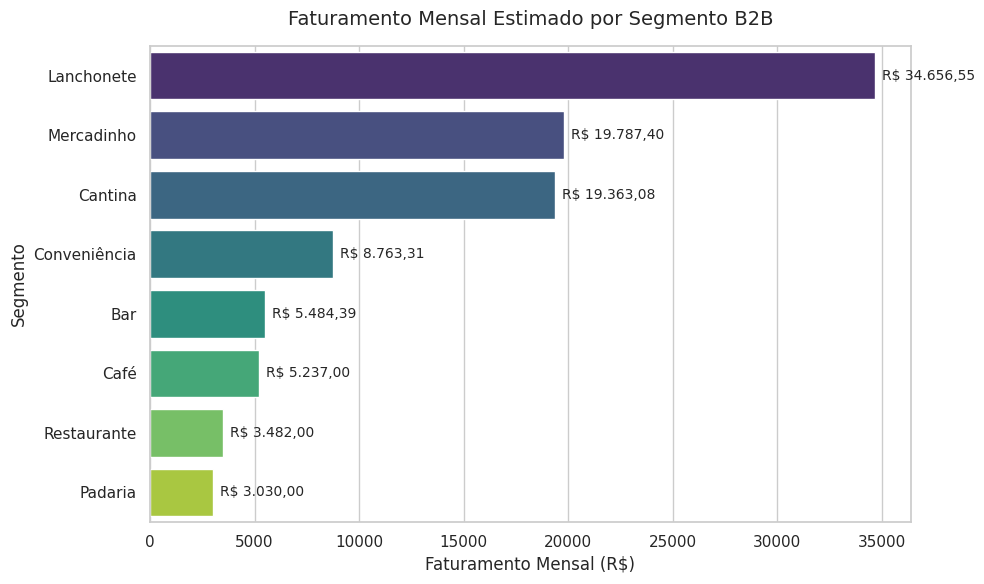

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = "whitegrid")

df = pd.read_csv('../data/clientes_anonimizados.csv')

if not pd.api.types.is_numeric_dtype(df['Ticket Médio Mensal']):
    df['Ticket Médio Mensal'] = (
        df['Ticket Médio Mensal']
        .astype(str)
        .str.replace('R$ ', '', regex = False)
        .str.replace('R$', '', regex = False) 
        .str.replace('.', '', regex = False)  
        .str.replace(',', '.', regex = False) 
        .astype(float)
    )

if not pd.api.types.is_numeric_dtype(df['Frequência Numérica']):
    df['Frequência Numérica'] = (
        df['Frequência Numérica']
        .astype(str)
        .str.replace(',', '.', regex = False)
        .astype(float)
    )

df['Faturamento Mensal Estimado'] = df['Frequência Numérica'] * df['Ticket Médio Mensal']

faturamento_segmento = (
    df.groupby('Segmento')['Faturamento Mensal Estimado']
    .sum()
    .sort_values(ascending = False)
    .reset_index()
)

plt.figure(figsize = (10, 6))
ax = sns.barplot(
    x = 'Faturamento Mensal Estimado', 
    y = 'Segmento', 
    data = faturamento_segmento, 
    palette = 'viridis',
    hue = 'Segmento', 
    legend = False
)

for p in ax.patches:
    valor = p.get_width()
    texto_valor = f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    ax.annotate(texto_valor, 
                (valor, p.get_y() + p.get_height() / 2.), 
                ha = 'left', va = 'center', 
                xytext = (5, 0), textcoords ='offset points',
                fontsize = 10)

plt.title('Faturamento Mensal Estimado por Segmento B2B', fontsize = 14, pad = 15)
plt.xlabel('Faturamento Mensal (R$)', fontsize = 12)
plt.ylabel('Segmento', fontsize = 12)
plt.tight_layout()

plt.show()

In [9]:
# Previsibilidade do Caixa

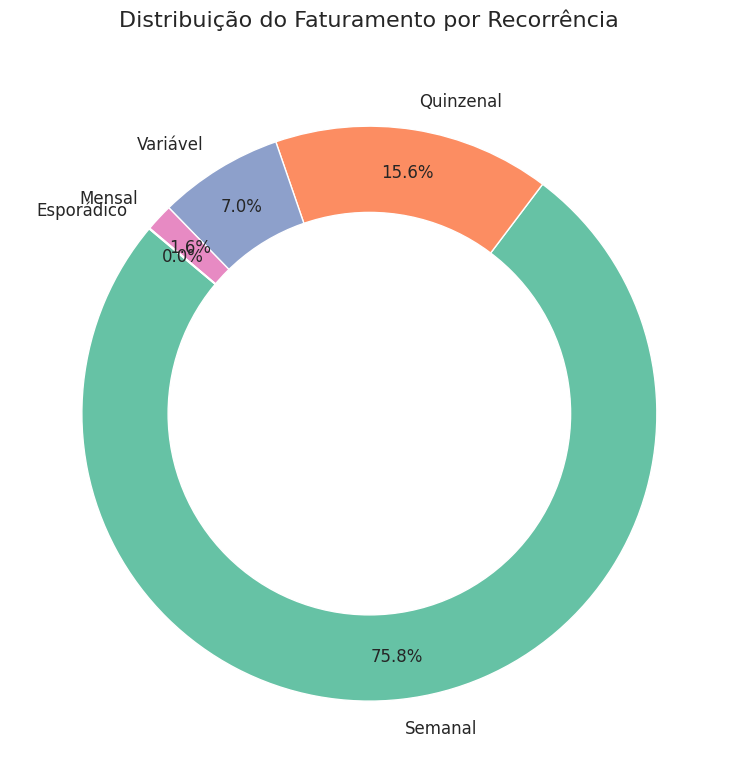

In [58]:
faturamento_recorrencia = (
    df.groupby('Recorrência')['Faturamento Mensal Estimado']
    .sum()
    .sort_values(ascending = False)
    .reset_index()
)

plt.figure(figsize = (8, 8))

cores = sns.color_palette('Set2')[0:len(faturamento_recorrencia)]

plt.pie(
    faturamento_recorrencia['Faturamento Mensal Estimado'], 
    labels = faturamento_recorrencia['Recorrência'], 
    autopct = '%1.1f%%', 
    startangle = 140,    
    colors = cores,
    pctdistance = 0.85, 
    textprops = {'fontsize': 12}
)

centro_circulo = plt.Circle((0, 0), 0.70, fc = 'white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Distribuição do Faturamento por Recorrência', fontsize = 16, pad = 20)
plt.tight_layout()

plt.show()

In [ ]:
# Risco de Evasão de Clientes (Churn)

In [60]:
import pandas as pd
import numpy as np

def limpar_moeda(valor):
    if pd.isna(valor): 
        return np.nan
    
    if isinstance(valor, (int, float)): 
        return float(valor)
    
    v = str(valor).replace('R$', '').strip()
    if ',' in v:
        v = v.replace('.', '') 
        v = v.replace(',', '.') 
    
    return float(v)

df['Ticket Médio Mensal'] = df['Ticket Médio Mensal'].apply(limpar_moeda)


df['Frequência Numérica'] = df['Frequência Numérica'].astype(str).str.replace(',', '.').astype(float)


df['Recência'] = pd.to_datetime(df['Recência'], errors='coerce')
df.loc[df['Dias sem Comprar'] < 0, 'Dias sem Comprar'] = 0
hoje = pd.to_datetime('today')
df['Dias sem Comprar'] = (hoje - df['Recência']).dt.days 


df = df.dropna(subset=['Ticket Médio Mensal', 'Dias sem Comprar'])

In [61]:
import plotly.express as px

eixo_x = 'Dias sem Comprar' 
eixo_y = 'Ticket Médio Mensal'
categoria = 'Segmento'
nome_cliente = 'Nome Fantasia'

fig = px.scatter(
    df,
    x = eixo_x,
    y = eixo_y,
    size = 'Frequência Numérica',
    color = categoria,                   
    hover_name = nome_cliente,               
    title = 'Matriz de Risco: Dias Inativos vs. Ticket Médio',
    opacity = 0.7, 
    size_max = 40, 
    template = 'plotly_white' 
)

fig.update_layout(
    title = dict(font = dict(size = 22), x = 0.5), 
    xaxis = dict(title = dict(font = dict(size = 14), text = 'Dias sem Comprar'), tickfont = dict(size = 12)),
    yaxis = dict(title = dict(font=dict(size = 14), text = 'Ticket Médio Mensal (R$)'), tickfont = dict(size = 12)),
    legend = dict(title = dict(font=dict(size = 14)), font = dict(size = 12)),
    hoverlabel = dict(font_size = 14)
)

fig.add_vline(x=15, line_width = 2, line_dash="dash", line_color = "#FF5733", 
              annotation_text = "Alerta: +15 Dias Inativos", annotation_position = "top right")

fig.add_hline(y=1000, line_width = 2, line_dash = "dash", line_color = "#33C1FF", 
              annotation_text = "Ticket Alto (> R$ 1000)", annotation_position = "top right")

fig.write_html("matriz_de_risco_clientes.html")
fig.show()

In [62]:
df.describe()

,Frequência Numérica,Ticket Médio Mensal,Recência,Faturamento Mensal Estimado,Dias sem Comprar
count,62.000000,62.000000,62,62.000000,62.000000
mean,3.709677,456.237258,2026-03-23 22:03:52.258064,1609.737581,3.080645
min,0.500000,87.000000,2026-03-09 00:00:00,45.000000,-3.000000
25%,2.000000,161.685000,2026-03-24 00:00:00,474.875000,1.000000
50%,3.750000,269.210000,2026-03-26 00:00:00,964.180000,1.000000
75%,4.000000,535.535000,2026-03-26 00:00:00,1976.465000,3.000000
max,8.000000,2295.000000,2026-03-30 00:00:00,9180.000000,18.000000
std,1.990857,465.035642,NaN,1818.131132,4.320361


In [63]:
df.head(10)

,Nome Fantasia,Status,Cidade,Bairro,Cep,Segmento,Recorrência,Ponto de Contato,Frequência Numérica,Ticket Médio Mensal,Recência,Faturamento Mensal Estimado,Dias sem Comprar
0,Pinto,Ativo,Campos do Jordão,Vila Abernéssia,12460-000,Café,Quinzenal,+55 (011) 4788 1480,2.0,1403.00,2026-03-19,2806.00,8
1,Garcia,Ativo,Caraguatatuba,Av. Gaspar de Souza,11666-250,Conveniência,Mensal,0800 480 4286,1.0,443.67,2026-03-11,443.67,16
2,Caldeira Castro S.A.,Ativo,Guararema,Av. Dona Laurinda,08900-000,Lanchonete,Semanal,51 0546 0197,4.0,759.28,2026-03-23,3037.12,4
3,Teixeira Monteiro S/A,Ativo,Jacareí,Jd. Paraíba,12327-681,Cantina,Variável,11 7285-1336,3.0,125.67,2026-03-27,377.01,0
4,Lima S.A.,Ativo,Jacareí,Av. Carlos Frederico Werneck Lacerda,12320-410,Cantina,Variável,(031) 4588-0310,2.5,324.00,2026-03-24,810.00,3
5,Cunha,Ativo,Jacareí,Av. Pereira Campos,12320-670,Padaria,Quinzenal,(071) 2174-8262,2.0,435.00,2026-03-09,870.00,18
6,Nunes,Ativo,Jacareí,Jardim do Marquês,12310-807,Mercadinho,Variável,(084) 5917 8856,3.0,145.00,2026-03-09,435.00,18
7,Mendonça,Ativo,Jacareí,Jd. Pereira do Amparo,12327-320,Restaurante,Variável,+55 41 8060 3754,2.5,180.00,2026-03-27,450.00,0
8,Souza,Ativo,Jacareí,Parque Califórnia,12311-200,Lanchonete,Semanal,+55 71 8629-5226,5.0,880.50,2026-03-26,4402.50,1
9,das Neves Ltda.,Ativo,Jacareí,Jd. Califórnia,12305-490,Cantina,Variável,+55 (061) 5545-6254,3.5,145.00,2026-03-24,507.50,3
